# Exoplanet Direct Imaging Contrast Curves 

This notebook combines [Vanessa Bailey's handy direct imaging flux ratio plotting resources](https://github.com/nasavbailey/DI-flux-ratio-plot) with [Zach Berta-Thompson's `exoatlas`](https://github.com/zkbt/exoatlas/) to try to place exoplanet coronagraphy in context. This was pulled together quickyl around 7 May 2026, in preparation for talk Zach gave at the National Solar Observatory on 8 May 2026. 

In [1]:
from exoatlas import * 
from exoatlas.visualizations import * 

# import tools for plotting contrast curves
import overplot_flux_ratio as vb

# for airy disk
from scipy.special import j1 

In [2]:
# set up some plotting defaults that can change easily throughout
 
def setup_axes():
    return plt.subplots(1,1, figsize=(10, 5), constrained_layout=True)

def add_legend():
    plt.legend(loc='upper left', bbox_to_anchor=(1,1), frameon=False)


The next cell uses `exoatlas` to make some planet populations. This works with version 0.7.6, but I'd be a little cautious about using much earlier versions than that. 

In [3]:

methods = get_exoplanets_by_method()
keys = ['Transit', 'Radial Velocity',  'Imaging']  #'Astrometry', 'Microlensing',

exoplanets = {k:methods[k] for k in keys}
for k in exoplanets:
    exoplanets[k].s = 50
exoplanets['Transit'].color = 'darkgray'
exoplanets['Radial Velocity'].color = 'darkcyan'
exoplanets['Imaging'].color = 'indigo'

solar = SolarSystem()
solar.table['distance'] = 10*u.pc
solar.annotate_planets = True
solar.color='black'

Let's make a simple plot of actual planet quantities, what we ultimately want to infer:

In [4]:
!mkdir plots

mkdir: plots: File exists


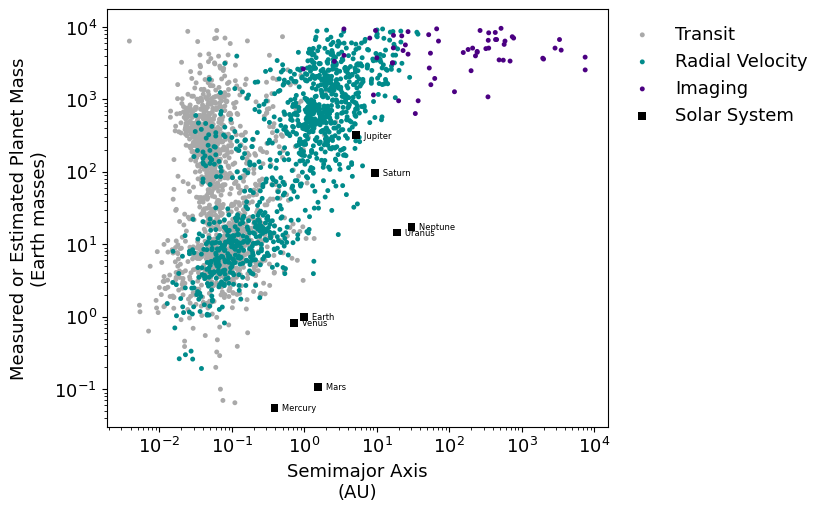

In [5]:
fi, ax = setup_axes()
m = BubbleMap(xaxis=SemimajorAxis(lim=[1e-2, 1e4]), 
              yaxis=Mass(kludge=True, lim=[1e-1, 1e4]), ax=ax)
m.build(exoplanets)
m.build(solar)
plt.axis('scaled')
plt.legend(bbox_to_anchor=(1,1),frameon=False);
plt.ylabel('Measured or Estimated Planet Mass\n(Earth masses)')
plt.savefig('plots/exoplanets-summary.pdf')


From here on, we'll focus on contrast as a function of angular separation. We'll start by defining a few helper functions: plotting the solar corona brightness (vaguely in the optical) and plotting our exoplanets in a uniform way.

In [6]:
def plot_solar_brightness(color='gray', labels=False):
    coronas = {}
    for k in ['k', 'f']:
        corona = QTable.read(f'data/plot-data-deforest-{k}-corona.csv')
        corona['angle'] = corona['x']*u.deg
        corona['contrast'] = corona['y']
        coronas[f'deforest-{k}'] = corona
    for k in ['k', 'f']:
        corona = QTable.read(f'data/plot-data-cranmer-{k}-corona.csv')
        corona['angle'] = np.arctan(corona['x']*u.Rsun/u.au).to('arcsec')
        corona['contrast'] = corona['y']
        coronas[f'cranmer-{k}'] = corona

    # plot limb-darkened disk
    r = np.linspace(0, 1.5, 1000)
    mu = 1-r 
    theta = np.arctan(r*u.Rsun/u.au).to('arcsec')
    solar_disk = 1 - 0.7*(1-mu)
    solar_disk[r > 1] = 0
    plt.loglog(theta, solar_disk, color=color, alpha=0.5, label='The Sun')
    fontkw = dict(color=color, fontsize='x-small', clip_on=True)


    for who in ['deforest']:
        for k in ['k', 'f']:
            corona = coronas[f'{who}-{k}']
            #plt.plot(corona['angle'], corona['contrast'], color='gray')

            # replace ragged data with smooth polynomial
            poly = np.polyfit(np.log(corona['angle'].value), np.log(corona['contrast']), deg=3)
            smooth = np.poly1d(poly)
            
            angle = np.logspace(np.log10(np.arctan(1*u.Rsun/u.au).to('arcsec').value), 5, 1000)*u.arcsec
            plt.plot(angle, np.exp(smooth(np.log(angle.to_value('deg')))), color=color, alpha=0.5)
        

    if labels:
        plt.text(3e2, 1.2, 'solar disk', ha='center', **fontkw)
        plt.text(5e3, 2e-10, 'F corona', ha='left', va='bottom', **fontkw)
        plt.text(5e3, 1e-11, 'K corona', ha='right', va='top', **fontkw)

    y =1e-4
    x = np.arctan(1*u.Rsun/u.au).to_value('arcsec')
    plt.text(x, y, r'  $\theta$=1R$_\odot$/1AU', rotation=90, ha='right', alpha=0.5, **fontkw)
    plt.axvline(x, alpha=0.2, color='gray', linestyle='--')
    x = np.arctan(1*u.Rsun/(10*u.pc)).to_value('arcsec')
    plt.text(x, y, r'  $\theta$=1R$_\odot$/10pc', rotation=90, ha='right',alpha=0.5, **fontkw)
    plt.axvline(x, alpha=0.2, linestyle='--', color='gray')

    plt.xlim(1e2, 1e5)
    plt.ylim(3e-14, 3)
    plt.xlabel('Angular Distance from the Center of the Sun (arcsec)')
    plt.ylabel('Intensity (relative to the Center of the Sun)')
    

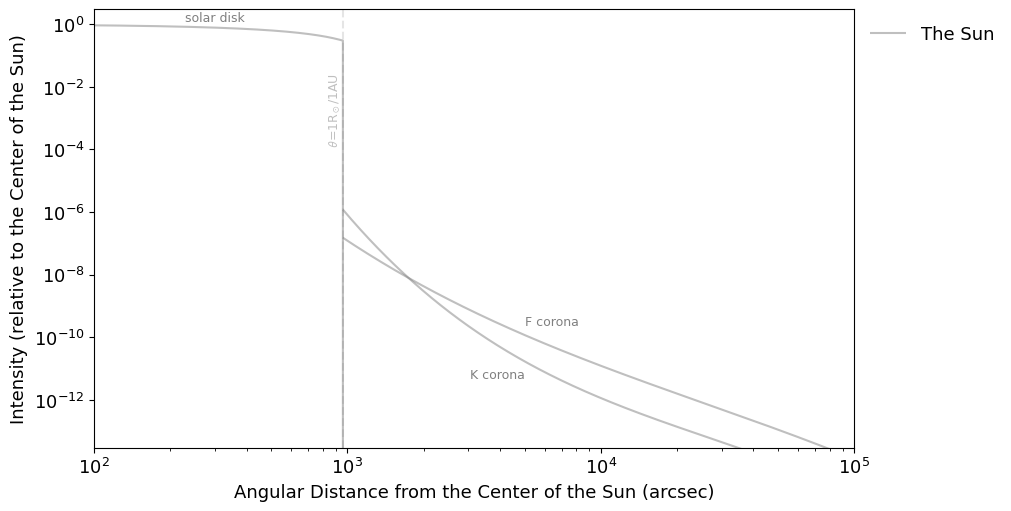

In [7]:
fi, ax = setup_axes()
plot_solar_brightness(labels=True)
add_legend()
plt.savefig('plots/exoplanets-solar-corona-for-reference.pdf')

In [8]:
def plot_exoplanets(ax):
    m = BubbleMap(xaxis=AngularSeparation(lim=[1e-5, 1e4], label='Angular Separation (arcsec)'), 
              yaxis=Contrast(kludge=True, albedo_geometric=0.25, phase_function=0.5, lim=[1e-12, 1], label='Reflected Light Planet-to-Star Contrast\n' + r'(assuming A$_g$=0.25, $\Phi(\alpha)$=0.5)'), 
              ax=ax)
    m.build(exoplanets)
    m.build(solar)

From here onward, each cell builds up by adding/removing components from the plot. 

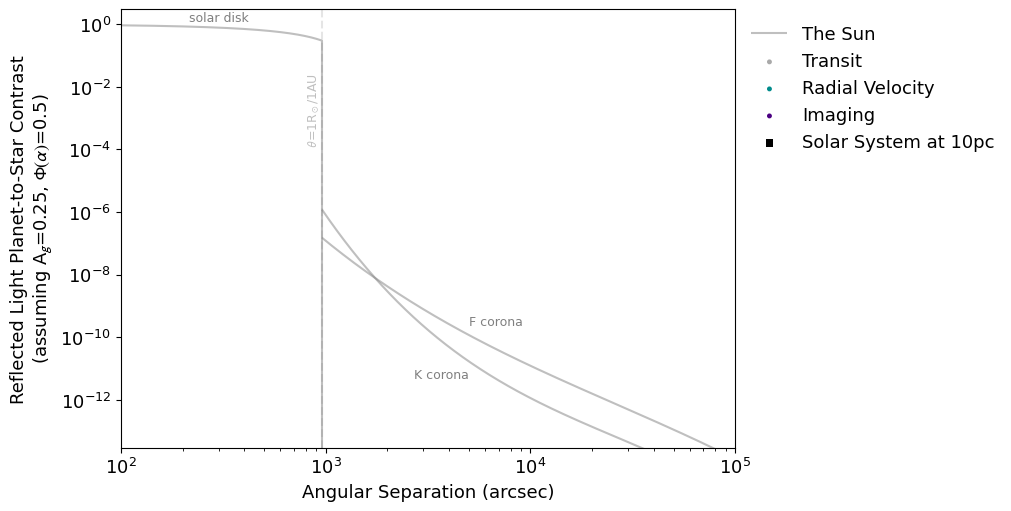

In [9]:
solar.label = 'Solar System at 10pc'

fi, ax = setup_axes()
plot_solar_brightness(labels=True)
plot_exoplanets(ax=ax)


plt.xlim(1e2, 1e5)
plt.ylim(3e-14, 3)
add_legend()

plt.savefig('plots/exoplanets-wide-separation.pdf')


In [10]:
def zoom_to_imaging():
    plt.xlim(1e-2, 1e1)
    plt.ylim(1e-12, 1e-3)

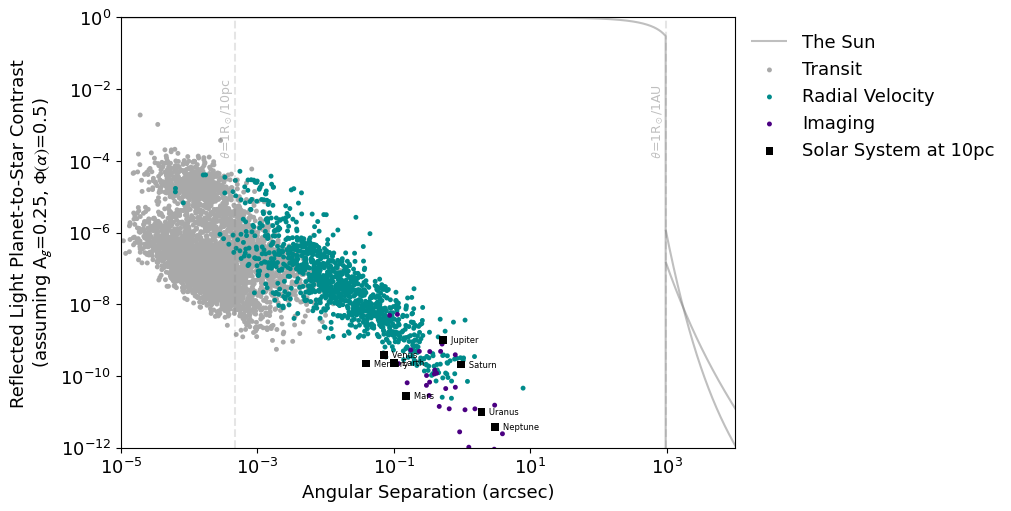

In [11]:

fi, ax = setup_axes()
plot_solar_brightness()
plot_exoplanets(ax=ax)
add_legend()
plt.savefig('plots/exoplanets-close-separation.pdf')



In [12]:
def plot_airy(wavelength = 1*u.micron,D = 1*u.m , N=10000000, extend=24, **kw):

    outer = extend*(wavelength/D*u.radian).to_value('arcsec')
    theta = (np.logspace(-3, np.log10(outer), N)*u.arcsec)

    x = np.pi/wavelength*D*theta.to_value(u.radian) 
    psf = 2*j1(x)/x.decompose()
    epsilon = 0.0001
    psf = ((2*j1(x)/x - epsilon**2 *2*j1(epsilon*x)/epsilon/x)**2/(1-epsilon**2)**2).decompose()
    plt.loglog(theta, psf, label=f'Diffraction Limit\n(D={D.to_string(format="latex_inline")}, $\lambda$={wavelength.to_string(format="latex_inline")})', **kw)
    
    

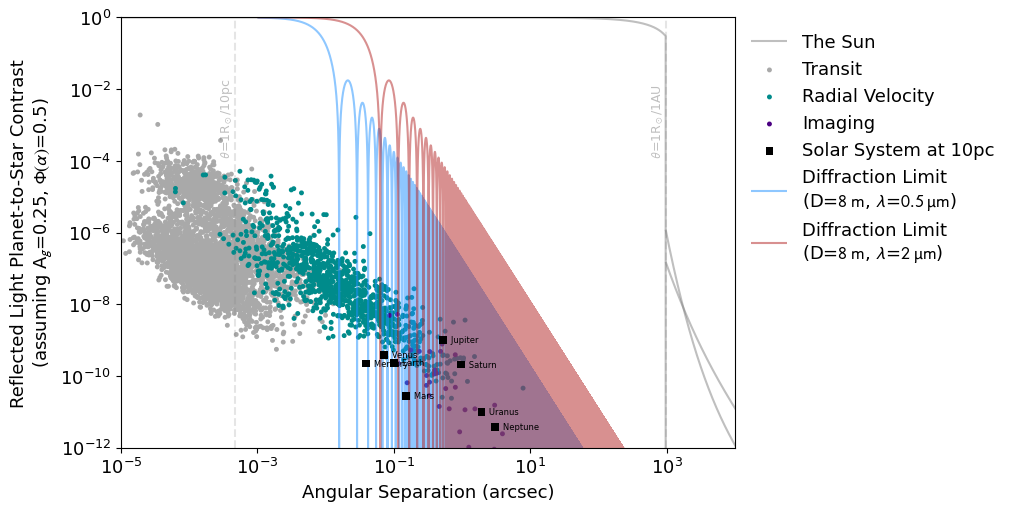

In [13]:
fi, ax = setup_axes()
plot_solar_brightness()
plot_exoplanets(ax=ax)
plot_airy(D=8*u.m, extend=10000, color=vb.c_v, wavelength=0.5*u.micron, alpha=0.5)
plot_airy(D=8*u.m, extend=10000, color=vb.c_k, wavelength=2*u.micron, alpha=0.5)
add_legend()

# the very dense sampling on the lines makes PDFs be cranky in Keynote, so do png instead
plt.savefig('plots/exoplanets-with-diffraction-limits.png', dpi=300)



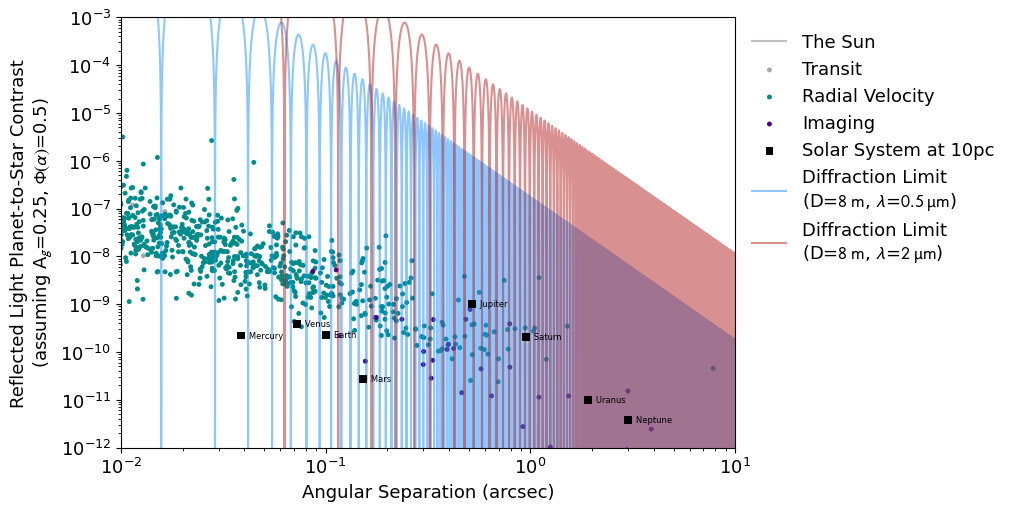

In [14]:
fi, ax = setup_axes()
plot_solar_brightness()
plot_exoplanets(ax=ax)
plot_airy(D=8*u.m, extend=10000, color=vb.c_v, wavelength=0.5*u.micron, alpha=0.5)
plot_airy(D=8*u.m, extend=10000, color=vb.c_k, wavelength=2*u.micron, alpha=0.5)
zoom_to_imaging()
add_legend()

# the very dense sampling on the lines makes PDFs be cranky in Keynote, so do png instead
plt.savefig('plots/exoplanets-with-diffraction-limits-zoomed.png', dpi=300)



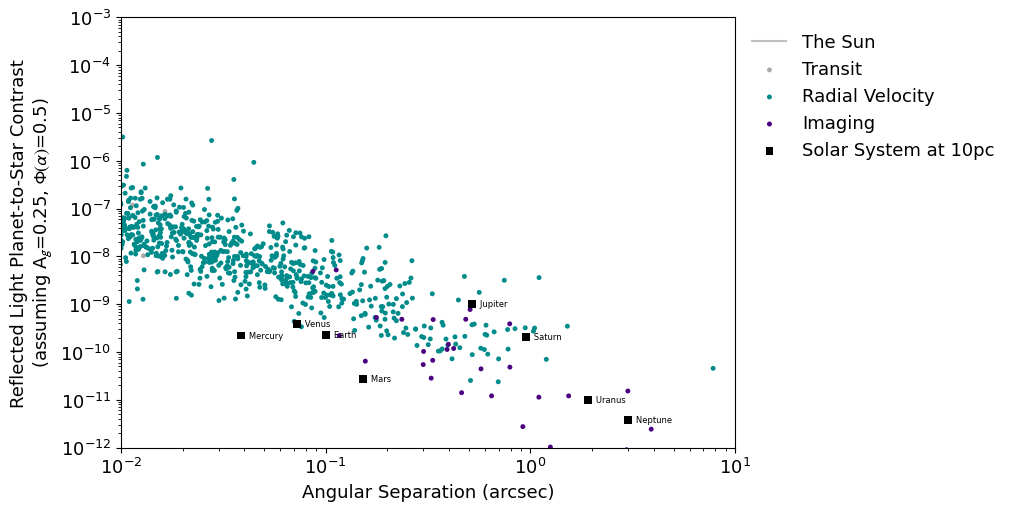

In [15]:
fi, ax = setup_axes()
plot_solar_brightness()
plot_exoplanets(ax=ax)
zoom_to_imaging()
add_legend()
plt.savefig('plots/exoplanets-zoomed.pdf')




**** WARNING **** no caption for ./data/ruffio-nirspec.csv



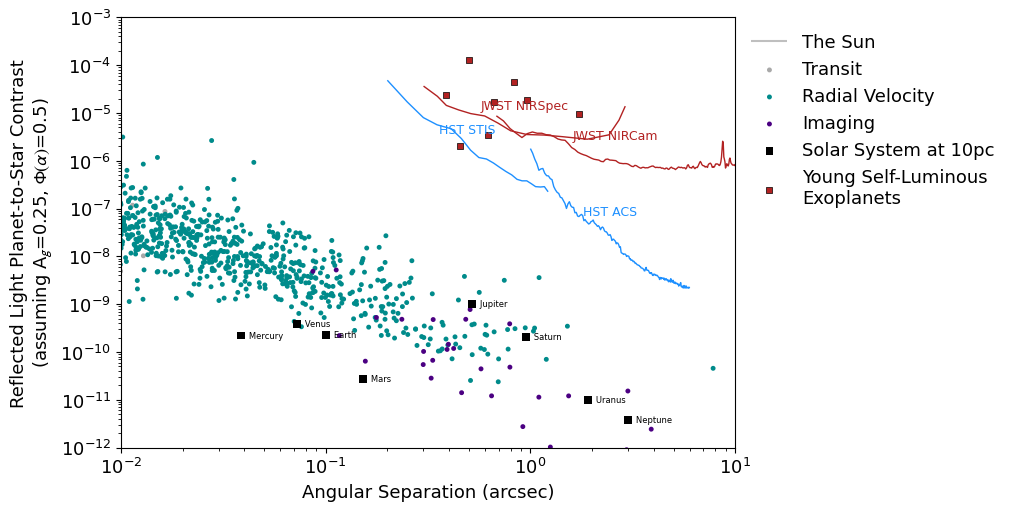

In [16]:

fi, ax = setup_axes()
plot_solar_brightness()
plot_exoplanets(ax=ax)
zoom_to_imaging()
vb.plot_self_luminous_planets()
add_legend()

vb.plot_STIS_contrast()
vb.plot_ACS_contrast()
vb.plot_NIRCam_contrast()
vb.plot_NIRSpec_contrast()
plt.savefig('plots/exoplanets-existing-space.pdf')


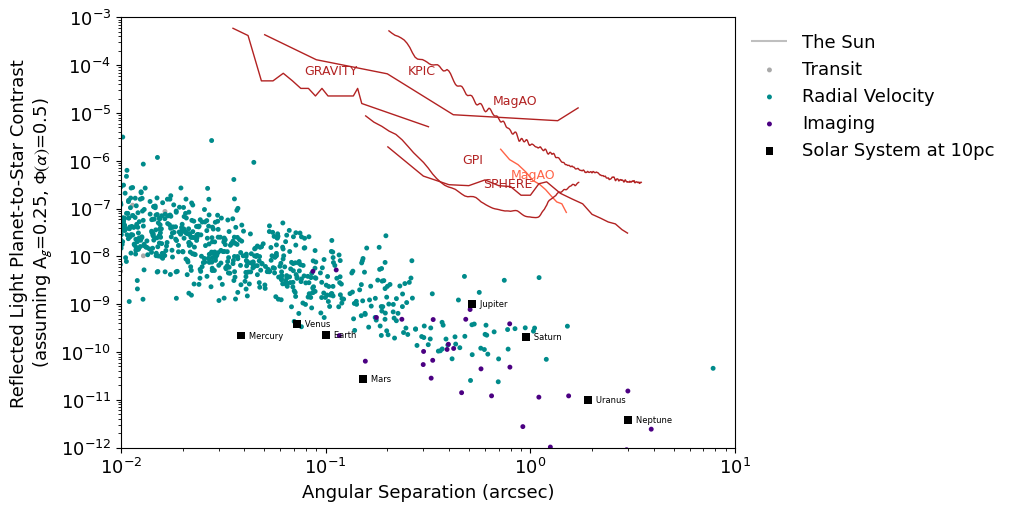

In [17]:
fi, ax = setup_axes()
plot_solar_brightness()
plot_exoplanets(ax=ax)
zoom_to_imaging()
add_legend()

vb.plot_MagAO_contrast()
vb.plot_GPI_contrast()
vb.plot_SPHERE_contrast()
vb.plot_GRAVITY_contrast()
vb.plot_KPIC_contrast()
plt.savefig('plots/exoplanets-existing-ground.pdf')



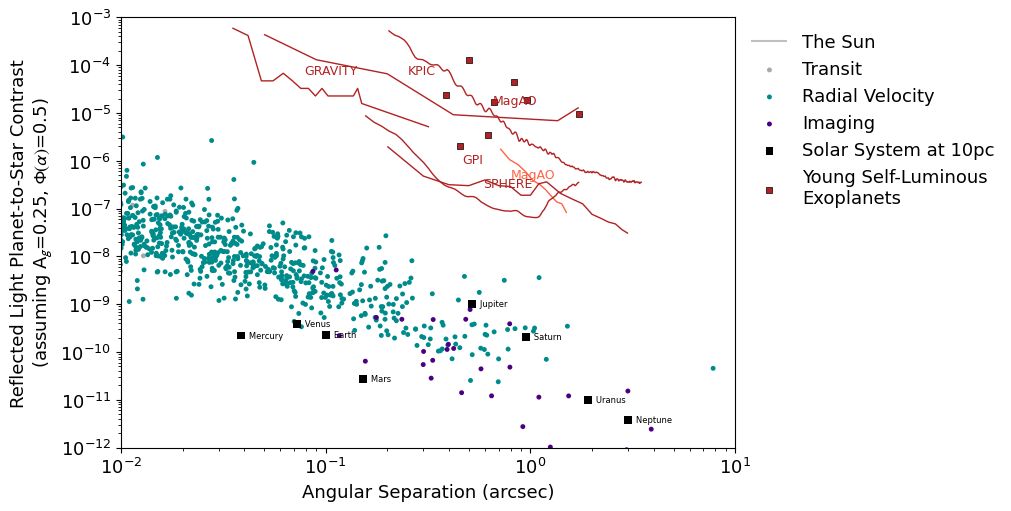

In [18]:
fi, ax = setup_axes()
plot_solar_brightness()
plot_exoplanets(ax=ax)
zoom_to_imaging()
vb.plot_self_luminous_planets()
add_legend()

vb.plot_MagAO_contrast()
vb.plot_GPI_contrast()
vb.plot_SPHERE_contrast()
vb.plot_GRAVITY_contrast()
vb.plot_KPIC_contrast()

plt.savefig('plots/exoplanets-existing-ground-with-luminous.pdf')



**** WARNING **** no caption for ./data/ruffio-nirspec.csv


**** WARNING **** no caption for ./data/ruffio-nirspec.csv



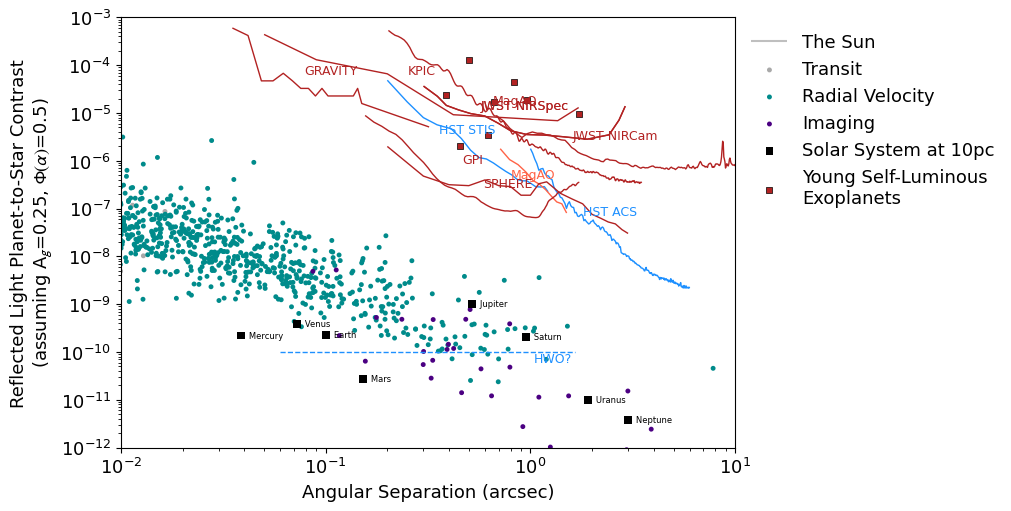

In [19]:
fi, ax = setup_axes()
plot_solar_brightness()
plot_exoplanets(ax=ax)
zoom_to_imaging()
vb.plot_self_luminous_planets()
add_legend()

vb.plot_STIS_contrast()
vb.plot_ACS_contrast()
vb.plot_NIRCam_contrast()
vb.plot_NIRSpec_contrast()

vb.plot_NIRSpec_contrast()
vb.plot_MagAO_contrast()
vb.plot_GPI_contrast()
vb.plot_SPHERE_contrast()
vb.plot_GRAVITY_contrast()
vb.plot_KPIC_contrast()


vb.plot_HWO_contrast()
plt.savefig('plots/exoplanets-hwo.pdf')


**** WARNING **** no caption for ./data/ruffio-nirspec.csv


**** WARNING **** no caption for ./data/ruffio-nirspec.csv



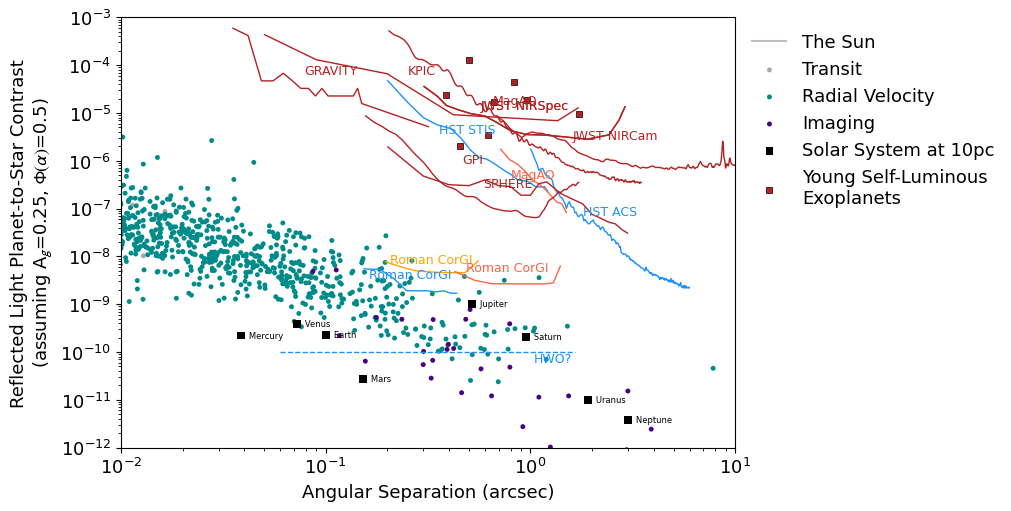

In [20]:
fi, ax = setup_axes()
plot_solar_brightness()
plot_exoplanets(ax=ax)
zoom_to_imaging()
vb.plot_self_luminous_planets()
add_legend()


vb.plot_STIS_contrast()
vb.plot_ACS_contrast()
vb.plot_NIRCam_contrast()
vb.plot_NIRSpec_contrast()

vb.plot_NIRSpec_contrast()
vb.plot_MagAO_contrast()
vb.plot_GPI_contrast()
vb.plot_SPHERE_contrast()
vb.plot_GRAVITY_contrast()
vb.plot_KPIC_contrast()


vb.plot_Roman_img_contrast()
vb.plot_Roman_spec_short_contrast()
vb.plot_Roman_wide_short_contrast()
vb.plot_HWO_contrast()
plt.savefig('plots/exoplanets-roman.pdf')